In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [264]:
root = '/project/def-marie87/vvshazia/pride_reanalysis/Ionbot_FDP'
entr_res_classic = f'{root}/IonbotData_tpp_fragpipe_ranks_groupwalk_151025/results/peptide_level'
entr_res_ionbot = f'{root}/IonbotData_ionbot_ranks_181025/results/peptide_level'

In [278]:
# read by-sample statistics
subsets_fdp_bythresh = pd.concat([pd.read_csv(f'{_}/all_bysample_stats_subsets.csv') for _ in [entr_res_classic, entr_res_ionbot] ])
# modify search type
subsets_fdp_bythresh['pipeline'] = subsets_fdp_bythresh['search_type'].map({'TPP_PTM':'TPP','FragPipe_PTM':'FragPipe','OpenSearch':'ionbot','ClosedSearch':'ionbot'})
subsets_fdp_bythresh['mode'] = subsets_fdp_bythresh['search_type'].map({'TPP_PTM':'Closed','FragPipe_PTM':'Open','OpenSearch':'Open','ClosedSearch':'Closed'})
# correct sample names
subsets_fdp_bythresh['sample'] = subsets_fdp_bythresh['sample'].str.split('_fdp').str[0].str.replace('esc-hf-','').str.replace('canonical_|noncanonical_', '', regex=True).str.lower()
#correct subset names
subsets_fdp_bythresh['subset'] = subsets_fdp_bythresh['subset'].map({'canonical':'Canonical','noncanonical':'Non-canonical'})
# samples with 0 IDs
subsets_fdp_bythresh['zero_ids_fdr'] = subsets_fdp_bythresh['Total target discoveries 1% FDR'] == 0
subsets_fdp_bythresh['zero_ids_fdp'] = subsets_fdp_bythresh['Total target discoveries 1% paired FDP'] == 0

# metadata - same for all filters
m = subsets_fdp_bythresh[['pipeline', 'mode','subset','sample','dataset']]
n = 24*2 #int(len(m)/6)
# long by filtering
# Classic / Group-Walk / Group-Wise FDR 1%
fdr = subsets_fdp_bythresh[['Paired method 1% FDR','zero_ids_fdr']]; fdr.columns = ["fdp","zero_ids"]; fdr['filter'] = ((['Global FDR 1%']*n + ['Group-Walk FDR 1%']*n + ['Group-Wise FDR 1%']*n)*2)*2
# Classic / Group-Walk / Group-Wise paired FDP 1%
fdp = subsets_fdp_bythresh[['Paired method 1% paired FDP','zero_ids_fdp']]; fdp.columns = ["fdp","zero_ids"]; fdp['filter'] = ((['Subset FDP 1%']*n + ['Group-Walk FDP 1%']*n + ['Group-Wise FDP 1%']*n)*2)*2

data = pd.concat([pd.concat([fdr, fdp],axis=0).reset_index(drop=True),pd.concat([m]*2,axis=0).reset_index(drop=True)],axis=1)
# str% to float
data['fdp'] = data.fdp.str.replace('%','').astype(float)

/tmp/ipykernel_694872/2540665519.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdr = subsets_fdp_bythresh[['Paired method 1% FDR','zero_ids_fdr']]; fdr.columns = ["fdp","zero_ids"]; fdr['filter'] = ((['Global FDR 1%']*n + ['Group-Walk FDR 1%']*n + ['Group-Wise FDR 1%']*n)*2)*2
/tmp/ipykernel_694872/2540665519.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdp = subsets_fdp_bythresh[['Paired method 1% paired FDP','zero_ids_fdp']]; fdp.columns = ["fdp","zero_ids"]; fdp['filter'] = ((['Subset FDP 

In [289]:
subsets_fdp_bythresh[(subsets_fdp_bythresh.search_type=='OpenSearch')].head().iloc[0]

Total discoveries                                           3024
Lower bound                                                0.40%
Paired method                                              0.80%
Total target discoveries 1% FDR                             3045
Lower bound 1% FDR                                         0.40%
Paired method 1% FDR                                       0.80%
Max rank 1% FDR                                           3040.0
Max search engine score 1% FDR                               NaN
Total target discoveries 1% paired FDP                      3124
Lower bound 1% paired FDP                                  0.50%
Paired method 1% paired FDP                                1.00%
Max rank 1% paired FDP                                    3119.0
Max search engine score 1% paired FDP                        NaN
sample                                    130327_o2_01_hu_c1_2hr
subset                                                 Canonical
dataset                  

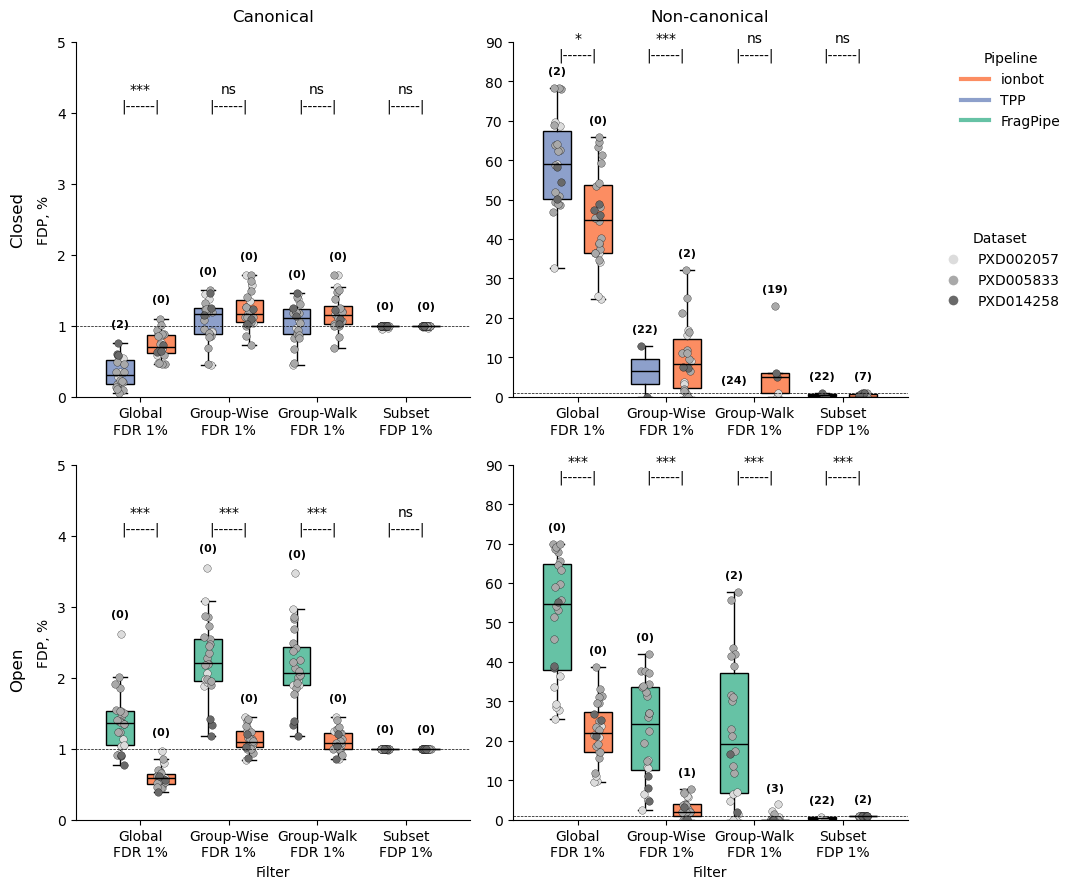

In [286]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from itertools import combinations
from scipy.stats import wilcoxon, mannwhitneyu

# --- helper function for p-value display ---
def pval_to_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

palette = {'PXD002057': 'gainsboro', 'PXD005833': 'darkgrey', 'PXD014258': 'dimgrey'}
#pipeline_palette = {
#    'ionbot Open - Canonical':'#fc8d62', 'ionbot Open - Non-canonical':'#fc8d62',
#    'FragPipe Open - Canonical':'#66c2a5','FragPipe Open - Non-canonical':'#66c2a5',
#    'ionbot Closed - Canonical':'#fc8d62', 'ionbot Closed - Non-canonical':'#fc8d62',
#    'TPP Closed - Canonical':'#8da0cb','TPP Closed - Non-canonical':'#8da0cb',
#}
pipeline_palette = {
    'ionbot':'#fc8d62', 
    'FragPipe':'#66c2a5',
    'TPP':'#8da0cb',
}
# remove empty samples from plotting
data_toplot = data.copy()
data_toplot = data_toplot[data_toplot["zero_ids"]==False]
#remove Group-Walk/Wise FDP filters
data_toplot = data_toplot[~((data_toplot["filter"].str.contains('Group'))&(data_toplot["filter"].str.contains('FDP')))]

# Get unique values to define subplot grid
modes = sorted(data["mode"].unique())
subsets = sorted(data["subset"].unique())

fig, axes = plt.subplots(
    nrows=len(modes),
    ncols=len(subsets),
    figsize=(5 * len(subsets), 4.5 * len(modes)),
)

# Ensure axes is always 2D
if len(modes) == 1:
    axes = np.expand_dims(axes, axis=0)
if len(subsets) == 1:
    axes = np.expand_dims(axes, axis=1)

for i, mode in enumerate(modes):
    df_mode = data_toplot[data_toplot["mode"] == mode]
    for j, subset in enumerate(subsets):
        ax = axes[i, j]
        df_subset = df_mode[df_mode["subset"] == subset]

        filters = ['Global FDR 1%','Group-Wise FDR 1%','Group-Walk FDR 1%',
                  'Subset FDP 1%']#,'Group-Wise FDP 1%','Group-Walk FDP 1%',]#sorted(df_subset["filter"].unique())
        pipelines = sorted(df_subset["pipeline"].unique())
        n_pipelines = len(pipelines)
        width = 0.7
        box_width = width / n_pipelines
        factor = 3
        offsets = np.linspace(-width/factor, width/factor, n_pipelines)

        y_max_total = 0  # track top y for significance annotation

        # --- Boxplots for each pipeline ---
        for k, pipeline in enumerate(pipelines):
            df_pipe = df_subset[df_subset["pipeline"] == pipeline]
            positions = np.arange(len(filters)) + offsets[k]
            box_data = [df_pipe.loc[df_pipe["filter"] == f, "fdp"].dropna() for f in filters]
            #boxcolor = pipeline_palette[f'{pipeline} {mode} - {subset}']
            boxcolor = pipeline_palette[pipeline]
            ax.boxplot(
                box_data,
                positions=positions,
                widths=box_width * 0.9,
                patch_artist=True,
                medianprops={'color': 'black'},
                boxprops={'facecolor': boxcolor, 'zorder': 1},
                whiskerprops={'zorder': 1},
                capprops={'zorder': 1},
                showfliers=False
            )

            # --- Add count of zero_ids == True above each box ---
            for f_i, f in enumerate(filters):
                count_zero = data[
                    (data["mode"] == mode) &
                    (data["subset"] == subset) &
                    (data["pipeline"] == pipeline) &
                    (data["filter"] == f) &
                    (data["zero_ids"] == True)
                ].shape[0]
                if len(box_data[f_i]) > 0:
                    y_max = np.nanmax(box_data[f_i])
                else:
                    y_max = 0
                ax.text(
                    f_i + offsets[k], y_max + (0.2 if subset == 'Canonical' else 3 ),
                    f'({count_zero})',
                    ha='center', va='bottom',
                    fontsize=8, color='black', fontweight='bold'
                )
                y_max_total = max(y_max_total, y_max)

        # --- Scatter points by dataset ---
        for dataset, df_ds in df_subset.groupby("dataset"):
            for k, pipeline in enumerate(pipelines):
                df_ds_pipe = df_ds[df_ds["pipeline"] == pipeline]
                for f_i, f in enumerate(filters):
                    y = df_ds_pipe.loc[df_ds_pipe["filter"] == f, "fdp"].values
                    x = np.full_like(y, f_i + offsets[k])
                    jitter = np.random.uniform(-0.05, 0.05, size=len(y))
                    ax.scatter(
                        x + jitter, y,
                        color=palette[dataset],
                        alpha=1, s=30, zorder=2,
                        edgecolor='black', linewidth=.2,
                    )
                    if len(y) > 0:
                        y_max_total = max(y_max_total, np.nanmax(y))

        # --- Significance tests on full data (Wilcoxon) ---
        comparisons = list(combinations(pipelines, 2))
        for f_i, f in enumerate(filters):
            for idx, (pipe1, pipe2) in enumerate(comparisons):
                #d1 = df_subset[(df_subset["pipeline"] == pipe1) & (df_subset["filter"] == f)]["fdp"].dropna()
                #d2 = df_subset[(df_subset["pipeline"] == pipe2) & (df_subset["filter"] == f)]["fdp"].dropna()
                d1 = data[(data["subset"]==subset)&(data["mode"]==mode)&(data["pipeline"] == pipe1) & (data["filter"] == f)]["fdp"].dropna()
                d2 = data[(data["subset"]==subset)&(data["mode"]==mode)&(data["pipeline"] == pipe2) & (data["filter"] == f)]["fdp"].dropna()

                if len(d1) == len(d2) and len(d1) > 0:
                    stat, p = wilcoxon(d1, d2)
                else:
                    print("Not pairwise data!")
                    print(f)

                # place above max data point
                #y_pos = df_subset["fdp"].max()#y_max_total + 0.5
                y_pos =  4 if subset == 'Canonical' else 85
                ax.text(
                    f_i, y_pos,
                    f"{pval_to_stars(p)}\n|------|",
                    ha='center', va='bottom',
                    fontsize=10, color='black'
                )
                #y_max_total = max(y_max_total, y_pos)

        # --- Horizontal line and formatting ---
        ax.axhline(y=1, color='black', linestyle='--', linewidth=.5)

        if subset == 'Canonical': ax.set_ylim((0,5)) # y_max_total * 1.2
        if subset == 'Non-canonical': ax.set_ylim((0, 90)) # y_max_total * 1.2

        ax.set_xticks(np.arange(len(filters)))
        ax.set_xticklabels(['Global\nFDR 1%','Group-Wise\nFDR 1%','Group-Walk\nFDR 1%',
                  'Subset\nFDP 1%'], ha='center')#, rotation=45)
        if i==1: ax.set_xlabel("Filter")
        if j == 0: ax.set_ylabel("FDP, %")
        if i == 0: ax.set_title(subset, fontsize=12,pad=15)
        sns.despine(ax=ax)
# ---- Row titles (modes) ----
for i, mode in enumerate(modes):
    # y-position: roughly center of the row
    # x-position: just to the left of the subplots
    fig.text(
        -0.005,                               # X-position (adjust if needed)
        (len(modes) - i - 0.5) / len(modes),  # Y-position (center of row)
        mode, 
        va='center', ha='center',
        rotation=90, fontsize=12,
    )
# ---- Legends ----
pipeline_labels = ['ionbot', 'TPP', 'FragPipe']
pipeline_handles = [
    Line2D([0], [0], color=pipeline_palette[label], lw=3)
    for label in pipeline_labels
]
fig.legend(pipeline_handles, pipeline_labels, title="Pipeline",
           loc='upper right', bbox_to_anchor=(1.05, 0.95), frameon=False)

dataset_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=palette[d], markersize=8)
    for d in palette
]
fig.legend(dataset_handles, list(palette.keys()), title="Dataset",
           loc='upper right', bbox_to_anchor=(1.05, 0.75), frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


In [ ]:
# Why Group-Walk/Wise get close to FDP 1% in open search than with closed search? - many IDs & high scoring?